In [1]:
import numpy as np
import numpy.typing as npt
import networkx as nx
import matplotlib.pyplot as plt
import casadi as ca

In [2]:
def headloss_pipes(
    inductance: float | npt.NDArray,
    resistance: float | npt.NDArray,
    volume_flow: float | npt.NDArray,
) -> float | npt.NDArray:
    if not (inductance.shape == resistance.shape == volume_flow.shape):
        raise ValueError("Input values not of the same shape.")
    with np.errstate(divide="raise", invalid="raise"):
        return (resistance / inductance) * abs(volume_flow) * volume_flow

In [3]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s # original: 1.5e3
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

In [4]:
## average operating conditions
# volume flow
q_mean = 0.0001  # 0224331792911098  # m^3/2

In [5]:
internal_nodes = {
    "consumer_valve_inlet": {
        "name": "consumer_valve_inlet",
        "elevation": 0.875,
        "demand": 0,
    },
    "consumer_valve_outlet": {
        "name": "consumer_valve_outlet",
        "elevation": 0.875,
        "demand": 0,
    },
    "consumer_outlet": {
        "name": "consumer_outlet",
        "elevation": 0.83,
        "demand": 0.0001,  # 0224331792911098
    },
}

In [6]:
reservoirs = {
    "tank_outlet": {
        "name": "tank_outlet",
        "elevation": 1.2,
        "pressure": 0.2,
    },
}

In [7]:
pipes = {
    "tank_outlet_pipe": {
        "start_node": "tank_outlet",
        "end_node": "consumer_valve_inlet",
        "type": "pipe",
        "length": 1.7,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    # "valve_pipe": {
    #     "start_node": "consumer_valve_inlet",
    #     "end_node": "consumer_valve_outlet",
    #     "type": "pipe",
    #     "length": 0.1,
    #     "diameter": 0.015,
    #     "roughness": 0.007e-3,
    #     "friction_factor": 1.65e-3  # 1.325e-1,  # 0.021
    # },
    "consumer_outlet_pipe": {
        "start_node": "consumer_valve_outlet",
        "end_node": "consumer_outlet",
        "type": "pipe",
        "length": 0.35,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
}

In [8]:
elements = {
    "consumer_valve": {
        "start_node": "consumer_valve_inlet",
        "end_node": "consumer_valve_outlet",
        "type": "valve",
        "diameter": 0.015,
        "length": 0.1,
        "system_coefficent": 0.2,
        "valve_coefficient": 6.357153214370093,  # 6.357154550561105, #6.357154551,# 2.9277, 6.357153214370093
        "initial_input": 0.5,
    }
}

In [9]:
pipe_number = len(pipes.keys())
internal_node_number = len(internal_nodes.keys())
reservoir_number = len(reservoirs.keys())
element_number = len(elements.keys())

In [10]:
for name, properties in elements.items():
    properties["cross_section_area"] = (properties["diameter"] / 2) ** 2 * np.pi
a_0 = elements["consumer_valve"]["cross_section_area"]
c_d = elements["consumer_valve"]["valve_coefficient"]

In [11]:
for name, properties in pipes.items():
    properties["cross_section_area"] = (properties["diameter"] / 2) ** 2 * np.pi

In [12]:
inverse_relative_roughnesses = {}
for name, properties in pipes.items():
    inverse_relative_roughnesses[name] = (
        properties["diameter"] / properties["roughness"]
    )

In [13]:
initial_condition_flow_pipes = np.full((len(pipes.keys()), 1), q_mean)
initial_condition_flow_elements = np.full((len(elements.keys()), 1), q_mean)

In [14]:
edge_dict = {}
for name, edge in pipes.items():
    edge_dict[name] = (edge["start_node"], edge["end_node"])
for name, edge in elements.items():
    edge_dict[name] = (edge["start_node"], edge["end_node"])
graph_edge_list = [edge for edge in edge_dict.values()]

In [15]:
graph = nx.Graph()
graph.add_nodes_from(reservoirs.keys())
graph.add_nodes_from(internal_nodes.keys())
graph.add_edges_from(edge_dict.values())

In [16]:
internal_nodes_list = [name for name in internal_nodes.keys()]
reservoir_nodes_list = [name for name in reservoirs.keys()]
node_list = internal_nodes_list + reservoir_nodes_list

In [17]:
pipe_list = [name for name in pipes.keys()]
element_list = [name for name in elements.keys()]
edge_list = pipe_list + element_list

In [18]:
incidence_matrix = -nx.incidence_matrix(
    graph, oriented=True, nodelist=node_list, edgelist=graph_edge_list
)
print(incidence_matrix.todense())

[[-1.  0.  1.]
 [ 0.  1. -1.]
 [ 0. -1.  0.]
 [ 1.  0.  0.]]


In [19]:
A_I = np.array(incidence_matrix.todense()[:internal_node_number])
A_R = np.array(incidence_matrix.todense()[-reservoir_number:])

In [20]:
A_I_p = A_I[:, :pipe_number]
A_I_e = A_I[:, -element_number:]
A_R_p = A_R[:, :pipe_number]
A_R_e = A_R[:, -element_number:]

In [21]:
inductance = []  # L
resistance = []  # R
capacitance = []  # C
for properties in pipes.values():
    inductance.append(properties["length"] / (g * properties["cross_section_area"]))
    resistance.append(
        8
        * properties["length"]
        * properties["roughness"]
        / (np.pi**2 * g * properties["diameter"] ** 5)
    )
    capacitance.append(
        (2 * g * np.pi / 4 * properties["diameter"] ** 2 * properties["length"])
        / (a**2)
    )
for properties in elements.values():
    capacitance.append(
        (2 * g * np.pi / 4 * properties["diameter"] ** 2 * properties["length"])
        / (a**2)
    )

In [22]:
system_coeffcients = []
for properties in elements.values():
    system_coeffcients.append(properties["system_coefficent"])

In [23]:
L = np.array(inductance).reshape(len(list(pipes.keys())), 1)
R = np.array(resistance).reshape(len(list(pipes.keys())), 1)
C = np.array(capacitance).reshape(len(list(edge_dict.keys())), 1)

In [24]:
f_p_initial = headloss_pipes(L, R, initial_condition_flow_pipes)
f_p_initial

array([[1.32039656e-08],
       [1.32039656e-08]])

In [25]:
reservoir_total_head = (
    reservoirs["tank_outlet"]["pressure"] + (reservoirs["tank_outlet"]["elevation"])
)
reservoir_total_head

1.4

In [26]:
internal_nodes["consumer_outlet"]["initial_head"] = (
    1.39799373  # internal_nodes["consumer_outlet"]["elevation"]  # (1/(2*g))*(q_mean/pipes["consumer_outlet_pipe"]["cross_section_area"])**2
)
internal_nodes["consumer_valve_outlet"]["initial_head"] = (
    1.39800676  # (internal_nodes["consumer_valve_outlet"]["elevation"])  # internal_nodes["consumer_outlet"]["initial_head"] + R[2,0] * q_mean**2 +
)
internal_nodes["consumer_valve_inlet"]["initial_head"] = (
    1.39962220  # (internal_nodes["consumer_valve_inlet"]["elevation"])  # internal_nodes["consumer_valve_outlet"]["initial_head"] + R[1,0] * q_mean**2 +
)

In [27]:
for name, properties in pipes.items():
    properties["friction_factor"] = (
        (
            internal_nodes[properties["start_node"]]["initial_head"]
            - internal_nodes[properties["end_node"]]["initial_head"]
        )
        / (
            (properties["length"] / properties["diameter"])
            * (1 / (2 * g))
            * (q_mean / properties["cross_section_area"]) ** 2
        )
        if properties["start_node"] in internal_nodes.keys()
        else (
            reservoirs["tank_outlet"]["pressure"]
            + (reservoirs["tank_outlet"]["elevation"])
            - internal_nodes[properties["end_node"]]["initial_head"]
        )
        / (
            (properties["length"] / properties["diameter"])
            * (1 / (2 * g))
            * (q_mean / properties["cross_section_area"]) ** 2
        )
    )
    print(f"{name}: {properties['friction_factor']}")

tank_outlet_pipe: 0.00020424342905920904
consumer_outlet_pipe: 3.4214597270233e-05


In [28]:
h_I_0 = np.array([node["initial_head"] for node in internal_nodes.values()]).reshape(
    internal_node_number, 1
)

In [29]:
h_R_0 = np.array([reservoir_total_head]).reshape(reservoir_number, 1)

In [30]:
Q_0 = np.array([node["demand"] for node in internal_nodes.values()]).reshape(
    internal_node_number, 1
)

In [31]:
z_0 = np.array([elements["consumer_valve"]["initial_input"]]).reshape(element_number, 1)

In [32]:
u_0 = np.concatenate((h_R_0, Q_0, z_0))

In [33]:
G = np.linalg.inv(np.diagflat((0.5 * (abs(A_I) @ C))))

In [34]:
D = np.diagflat(np.array(system_coeffcients).reshape(element_number, element_number))

In [35]:
A = np.block(
    [
        [
            np.zeros(shape=(pipe_number, pipe_number)),
            np.zeros(shape=(pipe_number, element_number)),
            np.linalg.inv(np.diagflat(L)) @ A_I_p.transpose(),
            np.zeros(shape=(pipe_number, element_number)),
        ],
        [
            np.zeros(shape=(element_number, pipe_number)),
            np.zeros(shape=(element_number, element_number)),
            A_I_e.transpose(),
            np.zeros(shape=(element_number, element_number)),
        ],
        [
            -G @ A_I_p,  # -G @ A_I_p,
            G @ A_I_e,  # -G @ A_I_e, -> is substituted in the F_q_valve term anyway
            np.zeros(shape=(internal_node_number, internal_node_number)),
            np.zeros(shape=(internal_node_number, element_number)),
        ],
        [
            np.zeros(shape=(element_number, pipe_number)),
            np.zeros(shape=(element_number, element_number)),
            np.zeros(shape=(element_number, internal_node_number)),
            -D,
        ],
    ]
)
A

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.01974712e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  4.95305742e-03, -4.95305742e-03,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00, -1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 3.20469046e+08,  0.00000000e+00,  3.20469046e+08,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00, -1.28187619e+09, -1.28187619e+09,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.64812652e+09,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.0000000

In [36]:
B = np.block(
    [
        [
            np.linalg.inv(np.diagflat(L)) @ A_R_p.transpose(),
            np.zeros(shape=(pipe_number, internal_node_number)),
            np.zeros(shape=(pipe_number, element_number)),
        ],
        [
            A_R_e.transpose(),
            np.zeros(shape=(element_number, internal_node_number)),
            np.zeros(shape=(element_number, element_number)),
        ],
        [
            np.zeros(shape=(internal_node_number, reservoir_number)),
            -G,
            np.zeros(shape=(internal_node_number, element_number)),
        ],
        [
            np.zeros(shape=(element_number, reservoir_number)),
            np.zeros(shape=(element_number, internal_node_number)),
            D,
        ],
    ]
)

In [37]:
F_p_0 = (
    np.linalg.inv(np.diagflat(L))
    @ np.diagflat(R)
    @ np.full((1, pipe_number), np.abs(q_mean) * q_mean)[0]
).reshape(pipe_number, 1)

In [38]:
np.sqrt(
    (1 / (2 * g * (1.39962220 - 1.39800676)))
    * (1 / (a_0)) ** 2
    * (q_mean / elements["consumer_valve"]["initial_input"]) ** 2
)

6.357153214370093

In [39]:
F_e_0 = (
    (1 / (2 * g))
    * (1 / (c_d * a_0)) ** 2
    * (q_mean / elements["consumer_valve"]["initial_input"]) ** 2
)

In [40]:
F_0 = np.block(
    [
        [F_p_0],
        [F_e_0],
        [np.zeros(shape=(internal_node_number, 1))],
        [np.zeros(shape=(element_number, 1))],
    ]
)
F_0

array([[1.32039656e-08],
       [1.32039656e-08],
       [1.61544000e-03],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00]])

In [41]:
x_0 = np.block(
    [
        [np.full(shape=(pipe_number, 1), fill_value=q_mean)],
        [np.full(shape=(element_number, 1), fill_value=q_mean)],
        [h_I_0],
        [z_0],
    ]
)

In [42]:
E = np.block(
    [
        [
            np.eye(pipe_number),
            np.zeros((pipe_number, element_number)),
            np.zeros((pipe_number, internal_node_number)),
            np.zeros((pipe_number, element_number)),
        ],
        [
            np.zeros((element_number, pipe_number)),
            np.zeros((element_number, element_number)),
            np.zeros((element_number, internal_node_number)),
            np.zeros((element_number, element_number)),
        ],
        [
            np.zeros((internal_node_number, pipe_number)),
            np.zeros((internal_node_number, element_number)),
            np.eye(internal_node_number),
            np.zeros((internal_node_number, element_number)),
        ],
        [
            np.zeros((element_number, pipe_number)),
            np.zeros((element_number, element_number)),
            np.zeros((element_number, internal_node_number)),
            np.eye(element_number),
        ],
    ]
)

In [43]:
def u_e(t):  # input
    return np.array([np.sin(t)])


# Residual: F(t,y,ydot) = E*ydot - (A*y + B*u(t)) == 0
def residual(t, y, ydot, out):
    out[:] = E @ ydot - (A @ y + B.flatten() * u_e(t))

In [44]:
alg_vars = np.isclose(np.linalg.norm(E, axis=1), 0.0)

In [45]:
rhs_0 = A @ x_0 - F_0 + B @ u_0
x_dot_0 = np.zeros_like(x_0)
diff_rows = ~alg_vars
E_mod = E[diff_rows]
E_dyn = E_mod[:, diff_rows]
x_dot_0[diff_rows] = np.linalg.solve(E_dyn, rhs_0[diff_rows])
x_dot_0[alg_vars] = 0.0

In [46]:
A_mod = A[diff_rows]
A_dyn = A_mod[:, diff_rows]
B_dyn = B[diff_rows]

#### Variables

In [47]:
# Dynamic state
flow_tank_outlet_pipe = ca.MX.sym("flow_tank_outlet_pipe")
flow_consumer_outlet_pipe = ca.MX.sym("flow_consumer_outlet_pipe")
head_control_valve_inlet = ca.MX.sym("head_control_valve_inlet")
head_control_valve_outlet = ca.MX.sym("head_control_valve_outlet")
head_consumer_outlet = ca.MX.sym("head_consumer_outlet")
valve_opening = ca.MX.sym("valve_opening")
x = ca.vertcat(
    flow_tank_outlet_pipe,
    flow_consumer_outlet_pipe,
    head_control_valve_inlet,
    head_control_valve_outlet,
    head_consumer_outlet,
    valve_opening,
)
# x_dot_sym = ca.MX.sym("x_dot_sym", x.shape[0])
# x_dot = ca.vertcat(x_dot_sym)

x_names = [
    "flow_tank_outlet_pipe",
    "flow_consumer_outlet_pipe",
    " head_control_valve_inlet",
    "head_control_valve_outlet",
    "head_consumer_outlet",
    "valve_opening",
]

In [48]:
lb_flow = np.full((pipe_number), 0)
ub_flow = np.full((pipe_number), 5 * q_mean)
lb_head = np.full((internal_node_number), 0)
ub_head = np.full((internal_node_number), reservoir_total_head)
lb_valve = np.full((element_number), 0)
ub_valve = np.full((element_number), 1)
lbx = ca.vertcat(*lb_flow, *lb_head, *lb_valve)
ubx = ca.vertcat(*ub_flow, *ub_head, *ub_valve)

In [49]:
# Algebraic state
flow_valve = ca.MX.sym("flow_valve")
alg_state = ca.vertcat(flow_valve)
lb_flow_valve = np.full(element_number, 0)
ub_flow_valve = np.full(element_number, 5 * q_mean)
lb_alg_state = ca.vertcat(lb_flow_valve)
up_alg_state = ca.vertcat(ub_flow_valve)

In [50]:
# Control inputs
reservoir_head = ca.MX.sym("reservoir_head")
demand_control_valve_inlet = ca.MX.sym("demand_control_valve_inlet")
demand_control_valve_outlet = ca.MX.sym("demand_control_valve_outlet")
demand_consumer_outlet = ca.MX.sym("demand_consumer_outlet")
valve_input = ca.MX.sym("valve_input")
u = ca.vertcat(
    reservoir_head,
    demand_control_valve_inlet,
    demand_control_valve_outlet,
    demand_consumer_outlet,
    valve_input,
)

In [51]:
lb_reservoir_head = np.full(reservoir_number, 0.8 * reservoir_total_head)
lb_demand = np.full(internal_node_number, 0)
lb_valve_input = np.full(element_number, 0)
lbu = ca.vertcat(*lb_reservoir_head, *lb_demand, *lb_valve_input)
ub_reservoir_head = np.full(reservoir_number, 1.2 * reservoir_total_head)
ub_demand = np.full(internal_node_number, 5 * q_mean)
ub_valve_input = np.full(element_number, 1)
ubu = ca.vertcat(*ub_reservoir_head, *ub_demand, *ub_valve_input)

In [52]:
pipe_flows = ca.vertcat(flow_tank_outlet_pipe, flow_consumer_outlet_pipe)

In [53]:
L_inv_times_R = np.linalg.inv(np.diagflat(L)) @ np.diagflat(R)

In [54]:
# Non-linear termns
F_p_tank_outlet_pipe = (
    L_inv_times_R[0, 0] * ca.fabs(flow_tank_outlet_pipe) * flow_tank_outlet_pipe
)
F_p_consumer_outlet_pipe = (
    L_inv_times_R[1, 1] * ca.fabs(flow_consumer_outlet_pipe) * flow_consumer_outlet_pipe
)
F_q_valve = (
    G @ A_I_e @ alg_state
)  ## - because alg_ state is not in dyn state x; F_p is multiplied by (-1) in the alg_eq hence this sign must be changed to (-1)
F_p = ca.vertcat(
    F_p_tank_outlet_pipe, F_p_consumer_outlet_pipe, F_q_valve, *([0] * element_number)
)

In [55]:
F_p

MX(vertcat(((1.3204*fabs(flow_tank_outlet_pipe))*flow_tank_outlet_pipe), ((1.3204*fabs(flow_consumer_outlet_pipe))*flow_consumer_outlet_pipe), ([3.20469e+08, -1.28188e+09, 0]*flow_valve), 0))

In [56]:
# Equations
alg_eq = (
    ((1 / (2 * g)) * (1 / (c_d * a_0)) ** 2 * (flow_valve / valve_opening) ** 2)
    - head_control_valve_inlet
    + head_control_valve_outlet
)

In [57]:
x_dot = A_dyn @ x + B_dyn @ u - F_p

In [58]:
(
    G @ A_I_p @ np.full((pipe_number, 1), [q_mean])
    + G @ A_I_e @ np.full((element_number, 1), [q_mean])
    - G @ Q_0
)

array([[      0.        ],
       [      0.        ],
       [-329625.30485191]])

In [59]:
Q_0

array([[0.    ],
       [0.    ],
       [0.0001]])

In [60]:
G @ Q_0

array([[     0.        ],
       [     0.        ],
       [164812.65242596]])

In [64]:
# SIMULATION

dt = 5e-4
t = np.arange(0, 50, dt)
t0 = 0

dae = {"x": x, "z": alg_state, "p": u, "ode": x_dot, "alg": alg_eq}

opts = {
    "tf": 5e-4,  # 1e-4,  # time step for each integrator call
    "abstol": 1e-8,
    "reltol": 1e-8,
}

Fint = ca.integrator("Fint", "idas", dae, t0, dt, {"calc_ic": True})

# initial conditions
x0 = ca.DM(x_0[diff_rows])
z0 = ca.DM(x_0[alg_vars])
u0 = []
tc = 10
for tt in t:
    if tt < tc:
        u0.append(ca.DM(u_0))
    else:
        u0.append(ca.DM((u_0 * np.array([1, 1, 1, 1, 0.1]).reshape(5, 1)).flatten()))

x_vals = np.zeros((len(t), x0.numel()))
x_vals[0, :] = np.array(x0.T).ravel()
xt = x0

z_vals = np.zeros((len(t), z0.numel()))
z_vals[0, :] = np.array(z0.T).ravel()
zt = z0

for i, tt in enumerate(t):
    res = Fint(x0=xt, z0=zt, p=u0[i])
    xt = res["xf"]
    zt = res["zf"]
    x_vals[i, :] = np.array(xt.T).ravel()
    z_vals[i, :] = np.array(zt.T).ravel()

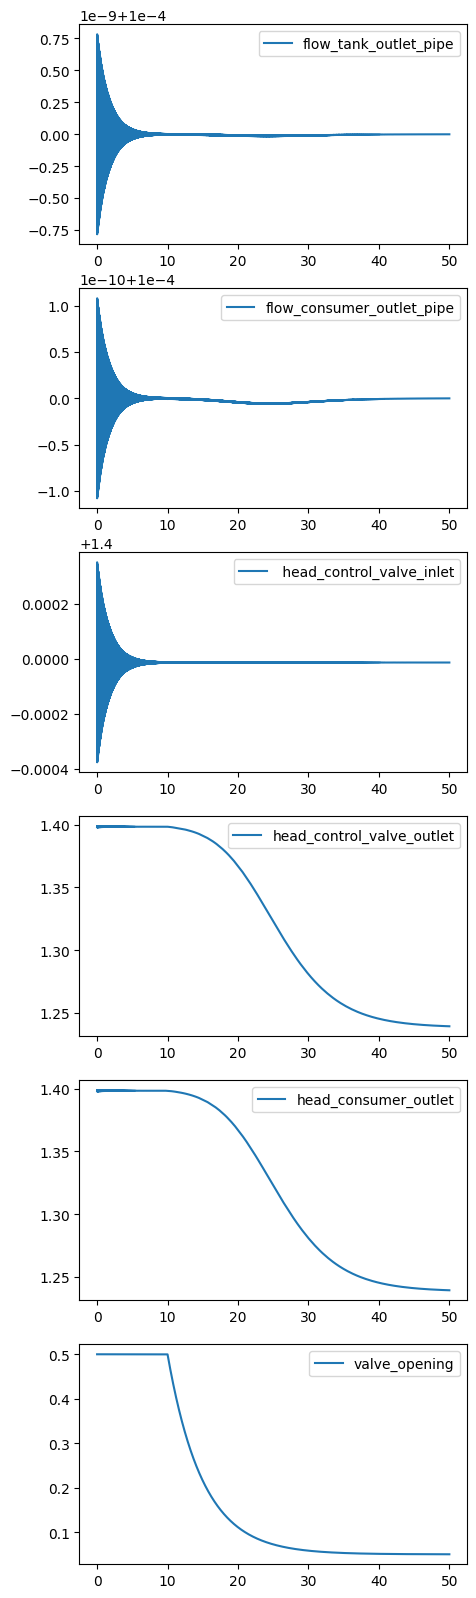

In [65]:
fig, axs = plt.subplots(len(x_0) - 1, figsize=(5, 20))

for i in range(len(x_0) - 1):
    axs[i].plot(t, x_vals[:, i], label=x_names[i])
    axs[i].legend()


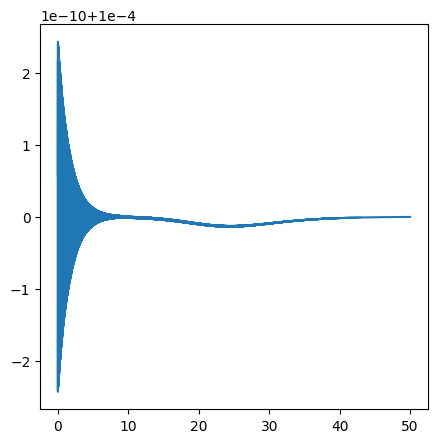

In [66]:
fig, axs = plt.subplots(len(x_0[alg_vars]), figsize=(5, 5))

for i in range(len(x_0[alg_vars])):
    axs.plot(t, z_vals[:, i])